In [13]:
import pandas as pd

esp_results = pd.read_csv("esp/results_esp_proteins.csv")
esp_results["model"] = "ESP (state of the art)"

np_esm2_results = pd.read_csv("neural_net_esm2_no_stereo/results_neural_net_esm2_proteins.csv")
np_esm2_results["model"] = "Neural Network-NPClassifier-ESM2"
np_esm2_results = np_esm2_results.rename(columns={"f1_macro": "f1_score"})

prosmith = pd.read_csv("prosmith/prosmith_proteins_results.csv")
prosmith["model"] = "ProSmith (state of the art)"

xgb_results = pd.read_csv("xgb_np_esm2_no_stereo/results_binding_np_classifier_proteins.csv")
xgb_results["model"] = "XGBoost-NPClassifierFP-ESM2"

xgb_results_prot_bert = pd.read_csv("xgb_np_prot_bert_no_stereo/results_binding_np_classifier_proteins.csv")
xgb_results_prot_bert["model"] = "XGBoost-NPClassifierFP-ProtBERT"

xgb_results_esm1b = pd.read_csv("xgb_np_esm1b_no_stereo/results_binding_np_classifier_proteins.csv")
xgb_results_esm1b["model"] = "XGBoost-NPClassifierFP-ESM1b"

similarity_results = pd.read_csv("similarity_method/similarity_evaluation_proteins.csv")
similarity_results["model"] = "BLASTp + Tanimoto"

In [14]:
results = pd.concat(
    [
        esp_results,
        # np_esm2_results,
        prosmith,
        xgb_results,
        # xgb_results_prot_bert,
        # xgb_results_esm1b,
        similarity_results
    ]
)
results


,accuracy,f1_score,recall,precision,roc_auc,mcc,seed,fold,identity,model
0,0.581194,0.612160,0.956026,0.450222,0.890352,0.365108,0.0,0.0,40,ESP (state of the art)
1,0.581194,0.611430,0.953094,0.450085,0.889122,0.362743,1.0,0.0,40,ESP (state of the art)
2,0.583896,0.613857,0.956678,0.451916,0.891651,0.368895,2.0,0.0,40,ESP (state of the art)
3,0.582095,0.612833,0.956678,0.450806,0.891281,0.366723,3.0,0.0,40,ESP (state of the art)
4,0.584347,0.613143,0.952769,0.452017,0.891295,0.366302,4.0,0.0,40,ESP (state of the art)
5,0.489880,0.526369,0.955733,0.363201,0.859667,0.274961,0.0,0.0,60,ESP (state of the art)
6,0.486233,0.524513,0.955426,0.361479,0.858700,0.270592,1.0,0.0,60,ESP (state of the art)
7,0.490974,0.527465,0.957885,0.363934,0.860019,0.278134,2.0,0.0,60,ESP (state of the art)
8,0.490974,0.527705,0.958807,0.364029,0.860994,0.278973,3.0,0.0,60,ESP (state of the art)
9,0.486324,0.524958,0.956963,0.361682,0.859652,0.272098,4.0,0.0,60,ESP (state of the art)


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Remove NaN identities
df = results.dropna(subset=["identity"]).copy()

# Aggregate mean and std per model + identity
agg = (
    df
    .groupby(["identity", "model"])
    .agg(
        f1_mean=("f1_score", "mean"),
        f1_std=("f1_score", "std"),
        mcc_mean=("mcc", "mean"),
        mcc_std=("mcc", "std"),
    )
    .reset_index()
)

identity_order = sorted(agg["identity"].unique())
models = [
    'BLASTp + Tanimoto',
    'ESP (state of the art)',
    'ProSmith (state of the art)',
    'XGBoost-NPClassifierFP-ESM2'
]

# Define colorblind-friendly colors for each model
fixed_colors = {
    'BLASTp + Tanimoto': "#bcbd22",  # Gold
    'ESP (state of the art)': "#1f77b4",  # Blue
    'ProSmith (state of the art)': "#2ca02c",  # Green
    'XGBoost-NPClassifierFP-ESM2': "#ff7f0e"  # Orange
}

# Define patterns for each model
patterns = {
    'BLASTp + Tanimoto': "//",  # Diagonal lines
    'ESP (state of the art)': "o",  # Circles
    'ProSmith (state of the art)': "\\",  # Backslash lines
    'XGBoost-NPClassifierFP-ESM2': "x"  # Crosses
}

# Map models to colors and patterns
palette = {model: fixed_colors[model] for model in models}
hatches = {model: patterns[model] for model in models}

metrics = {
    "mcc": ("mcc_mean", "mcc_std"),
    "f1_score": ("f1_mean", "f1_std")
}

for metric, (mean_col, std_col) in metrics.items():

    fig, ax = plt.subplots(figsize=(14, 6))

    group_width = 0.8
    x_positions = np.arange(len(identity_order))

    for i, identity in enumerate(identity_order):

        subset = agg[agg["identity"] == identity]

        # Sort within identity by mean performance
        subset_sorted = subset.sort_values(mean_col, ascending=False)

        n_models = len(subset_sorted)
        bar_width = group_width / n_models

        for j, (_, row) in enumerate(subset_sorted.iterrows()):

            xpos = x_positions[i] - group_width/2 + j*bar_width + bar_width/2

            ax.bar(
                xpos,
                row[mean_col],
                width=bar_width,
                color=palette[row["model"]],
                edgecolor="black",  # Add black edges
                hatch=hatches[row["model"]],  # Add pattern
                yerr=row[std_col],
                capsize=3,
                error_kw=dict(linewidth=1)
            )

    ax.set_xticks(x_positions)
    ax.set_xticklabels([int(i) for i in identity_order])
    ax.set_xlabel("Identity Threshold", fontsize=12)
    ax.set_ylabel(metric.upper(), fontsize=12)
    ax.set_title(f"{metric.upper()} – Models Ranked Within Each Protein Identity", fontsize=14)
    if metric == "mcc":
        ax.set_ylim(-1, 1)
    else:
        ax.set_ylim(0, 1)

    # Save the plot without the legend
    plt.tight_layout()
    plt.savefig(f"{metric}_comparison_proteins_no_legend.png", dpi=300, bbox_inches="tight", transparent=True)

    # Create a separate figure for the legend with both colors and patterns
    legend_handles = [
        Patch(
            facecolor=palette[m],
            label=m,
            edgecolor="black",
            hatch=hatches[m]
        ) for m in models
    ]
    fig_legend = plt.figure(figsize=(6, 2))
    fig_legend.legend(handles=legend_handles, loc="center", title="Method", ncol=len(models))
    fig_legend.savefig(f"{metric}_legend.png", dpi=300, bbox_inches="tight", transparent=True)

    plt.close(fig_legend)
    plt.close(fig)


In [10]:
import pandas as pd

import pandas as pd

esp_results = pd.read_csv("esp/results_esp_compounds.csv")
esp_results["model"] = "ESP (state of the art)"

np_esm2_results = pd.read_csv("neural_net_esm2_no_stereo/results_neural_net_esm2_compounds.csv")
np_esm2_results["model"] = "Neural Network-NPClassifier-ESM2"
np_esm2_results = np_esm2_results.rename(columns={"f1_macro": "f1_score"})

prosmith = pd.read_csv("prosmith/prosmith_compounds_results.csv")
prosmith["model"] = "ProSmith (state of the art)"

xgb_results = pd.read_csv("xgb_np_esm2_no_stereo/results_binding_np_classifier_compounds.csv")
xgb_results["model"] = "XGBoost-NPClassifierFP-ESM2"

xgb_results_prot_bert = pd.read_csv("xgb_np_prot_bert_no_stereo/results_binding_np_classifier_compounds.csv")
xgb_results_prot_bert["model"] = "XGBoost-NPClassifierFP-ProtBERT"

xgb_results_esm1b = pd.read_csv("xgb_np_esm1b_no_stereo/results_binding_np_classifier_compounds.csv")
xgb_results_esm1b["model"] = "XGBoost-NPClassifierFP-ESM1b"

similarity_results = pd.read_csv("similarity_method/similarity_evaluation_compounds.csv")
similarity_results["model"] = "BLASTp + Tanimoto"

results = pd.concat(
    [   
        esp_results,
        # np_esm2_results,
        prosmith,
        xgb_results,
        # xgb_results_prot_bert,
        # xgb_results_esm1b,
        similarity_results
    ]
)
results


,accuracy,f1_score,recall,precision,roc_auc,mcc,seed,fold,similarity,model
0,0.773798,0.549775,0.874362,0.400937,0.906674,0.482967,0.0,0.0,20.0,ESP (state of the art)
1,0.759600,0.521208,0.828396,0.380216,0.881162,0.441465,1.0,0.0,20.0,ESP (state of the art)
2,0.782672,0.546006,0.827375,0.407445,0.888419,0.470097,2.0,0.0,20.0,ESP (state of the art)
3,0.742175,0.517221,0.874362,0.367224,0.899235,0.445511,3.0,0.0,20.0,ESP (state of the art)
4,0.734269,0.507918,0.868233,0.358953,0.888655,0.433362,4.0,0.0,20.0,ESP (state of the art)
...,...,...,...,...,...,...,...,...,...,...
19,0.868506,0.663084,0.819203,0.556944,0.923435,0.601863,4.0,NaN,20.0,XGBoost-NPClassifierFP-ESM2
0,0.628751,0.234276,0.359551,0.173741,NaN,0.030166,NaN,NaN,20.0,BLASTp + Tanimoto
1,0.602294,0.087719,0.140845,0.063694,NaN,-0.137788,NaN,NaN,40.0,BLASTp + Tanimoto
2,0.297875,0.248724,0.333631,0.198267,NaN,-0.374972,NaN,NaN,60.0,BLASTp + Tanimoto


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Remove NaN identities
df = results.dropna(subset=["similarity"]).copy()

# Aggregate mean and std per model + identity
agg = (
    df
    .groupby(["similarity", "model"])
    .agg(
        f1_mean=("f1_score", "mean"),
        f1_std=("f1_score", "std"),
        mcc_mean=("mcc", "mean"),
        mcc_std=("mcc", "std"),
    )
    .reset_index()
)

identity_order = sorted(agg["similarity"].unique())
models = sorted(agg["model"].unique())

# Define a colorblind-friendly palette
fixed_colors = {
    'BLASTp + Tanimoto': "#bcbd22",  # Gold
    'ESP (state of the art)': "#1f77b4",  # Blue
    'ProSmith (state of the art)': "#2ca02c",  # Green
    'XGBoost-NPClassifierFP-ESM2': "#ff7f0e"  # Orange
}

# Define patterns for each model
patterns = {
    'BLASTp + Tanimoto': "//",  # Diagonal lines
    'ESP (state of the art)': "o",  # Circles
    'ProSmith (state of the art)': "\\",  # Backslash lines
    'XGBoost-NPClassifierFP-ESM2': "x"  # Crosses
}

# Map models to colors and patterns
palette = {model: fixed_colors.get(model, "#d62728") for model in models}
hatches = {model: patterns.get(model, "") for model in models}

metrics = {
    "mcc": ("mcc_mean", "mcc_std"),
    "f1_score": ("f1_mean", "f1_std")
}

for metric, (mean_col, std_col) in metrics.items():

    fig, ax = plt.subplots(figsize=(14, 6))

    group_width = 0.8
    x_positions = np.arange(len(identity_order))

    for i, identity in enumerate(identity_order):

        subset = agg[agg["similarity"] == identity]

        # Sort within identity by mean performance
        subset_sorted = subset.sort_values(mean_col, ascending=False)

        n_models = len(subset_sorted)
        bar_width = group_width / n_models

        for j, (_, row) in enumerate(subset_sorted.iterrows()):

            xpos = x_positions[i] - group_width/2 + j*bar_width + bar_width/2

            ax.bar(
                xpos,
                row[mean_col],
                width=bar_width,
                color=palette[row["model"]],
                edgecolor="black",  # Add black edges
                hatch=hatches[row["model"]],  # Add pattern
                yerr=row[std_col],
                capsize=3,
                error_kw=dict(linewidth=1)
            )

    ax.set_xticks(x_positions)
    ax.set_xticklabels([int(i) for i in identity_order])
    ax.set_xlabel("Similarity Threshold", fontsize=12)
    ax.set_ylabel(metric.upper(), fontsize=12)
    ax.set_title(f"{metric.upper()} – Models Ranked Within Each Compound Similarity", fontsize=14)
    if metric == "mcc":
        ax.set_ylim(-1, 1)
    else:
        ax.set_ylim(0, 1)

    # Save the plot without the legend
    plt.tight_layout()
    plt.savefig(f"{metric}_comparison_compounds_no_legend.png", dpi=300, bbox_inches="tight", transparent=True)

    # Create a separate figure for the legend with both colors and patterns
    legend_handles = [
        Patch(
            facecolor=palette[m],
            label=m,
            edgecolor="black",
            hatch=hatches[m]
        ) for m in models
    ]
    fig_legend = plt.figure(figsize=(6, 2))
    fig_legend.legend(handles=legend_handles, loc="center", title="Method", ncol=1)
    fig_legend.savefig(f"{metric}_legend.png", dpi=300, bbox_inches="tight", transparent=True)

    plt.close(fig_legend)
    plt.close(fig)


In [17]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from math import pi


def generate_metric_radar_plot(models, compound_files, similarity, metric='mcc'):
    # Dicionário para armazenar os valores de MCC por modelo e composto
    all_mcc_values = {model: {} for model in models}

    # Loop por cada modelo
    for model in models:
        # Loop por cada tipo de composto
        for compound, file in compound_files.items():
            try:
                df = pd.read_csv(os.path.join(model, file))  # Assumindo que os ficheiros estão na mesma pasta
                df = df[df["similarity"] == similarity]
                all_mcc_values[model][compound] = df[metric].mean()
            except Exception as e:
                print(f"Erro ao processar {model}/{compound}: {e}")

    # Preparar dados para o radar chart
    categories = list(compound_files.keys())
    N = len(categories)

    # Ângulos para cada eixo no radar chart
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]  # Fechar o círculo

    # Inicializar o gráfico
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'polar': True})

    for i, model in enumerate(all_mcc_values):
        values = list(all_mcc_values[model].values())
        values += values[:1] 
        ax.plot(angles, values, linewidth=2, label=model)
        ax.fill(angles, values, alpha=0.1)

    # Configurar o gráfico
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_title('Comparação de MCC por Tipo de Composto e Modelo', size=16, y=1.1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

    plt.tight_layout()
    plt.savefig('compound_mcc_radar_chart_all_models.png', dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()

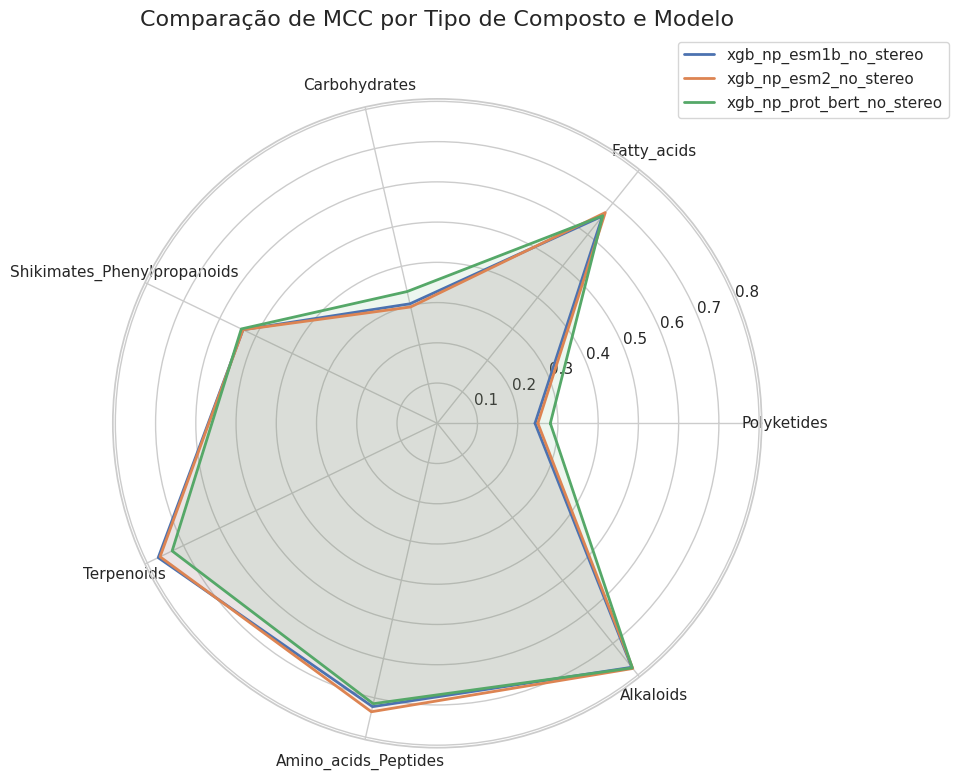

In [22]:
models = ["xgb_np_esm1b_no_stereo", "xgb_np_esm2_no_stereo", "xgb_np_prot_bert_no_stereo"]

# Dicionário de ficheiros de compostos
compound_files = {
    "Polyketides": "results_binding_np_classifier_compounds_Polyketides.csv",
    "Fatty_acids": "results_binding_np_classifier_compounds_Fatty acids.csv",
    "Carbohydrates": "results_binding_np_classifier_compounds_Carbohydrates.csv",
    "Shikimates_Phenylpropanoids": "results_binding_np_classifier_compounds_Shikimates and Phenylpropanoids.csv",
    "Terpenoids": "results_binding_np_classifier_compounds_Terpenoids.csv",
    "Amino_acids_Peptides": "results_binding_np_classifier_compounds_Amino acids and Peptides.csv",
    "Alkaloids": "results_binding_np_classifier_compounds_Alkaloids.csv"
}

generate_metric_radar_plot(models, compound_files, 60, metric='mcc')